# Pitch-shift results

Analyze BasicPitch, CREPE, and Librosa under pitch shift (25/50 cents), merged with `manifest_tuning.csv` (using class tags only). Generate summary tables, deltas vs clean, and dot plots with mean bars, saving outputs to `Tuned_Results`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:.3f}".format

out_dir = Path("Tuned_Results")
out_dir.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 150


In [2]:
manifest = pd.read_csv("manifest_tuning.csv")

shift_files = [
    ("basic_pitch", "25cents", "basic_pitch_pitch_shift_25cents.csv"),
    ("basic_pitch", "50cents", "basic_pitch_pitch_shift_50cents.csv"),
    ("crepe", "25cents", "crepe_pitch_shift_25cents.csv"),
    ("crepe", "50cents", "crepe_pitch_shift_50cents.csv"),
    ("librosa", "25cents", "librosa_pitch_shift_25cents.csv"),
    ("librosa", "50cents", "librosa_pitch_shift_50cents.csv"),
]

frames = []
for model, shift, path in shift_files:
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    df = df.merge(manifest, left_on="filename", right_on="track_id", how="left")
    df["model"] = model
    df["shift"] = shift
    frames.append(df)

metrics = pd.concat(frames, ignore_index=True)
metrics = metrics[["filename", "model", "shift", "class_tag", "OA", "RPA", "RCA", "VR"]]

# Clean baselines per model for loss computation
clean_files = {
    "basic_pitch": "basic_pitch_clean.csv",
    "crepe": "crepe_clean.csv",
    "librosa": "librosa_clean.csv",
}
clean_means = []
for model, path in clean_files.items():
    df = pd.read_csv(path)
    df = df[df["filename"].isin(manifest["track_id"])].copy()
    clean_means.append(
        df[["OA", "RPA", "RCA", "VR"]].mean().to_frame().T.assign(model=model)
    )
clean_means = pd.concat(clean_means, ignore_index=True).set_index("model")

metrics.head()


,filename,model,shift,class_tag,OA,RPA,RCA,VR
0,CelestialShore_DieForUs_STEM_02,basic_pitch,25cents,vocal,0.723,0.831,0.823,0.748
1,MusicDelta_GriegTrolltog_STEM_07,basic_pitch,25cents,instrument,0.716,0.471,0.469,0.743
2,AimeeNorwich_Child_STEM_04,basic_pitch,25cents,vocal,0.869,0.923,0.920,0.888
3,SecretMountains_HighHorse_STEM_09,basic_pitch,25cents,vocal,0.707,0.791,0.755,0.768
4,CelestialShore_DieForUs_STEM_01,basic_pitch,25cents,vocal,0.708,0.765,0.736,0.741


## Summary tables
- Overall mean metrics per model (best highlighted)
- Mean metrics by shift magnitude (25/50 cents)
- Mean metrics by source type (instrument vs vocal)
- Loss vs clean (overall and by shift; delta best/worst highlighted)

In [3]:
overall_table = (
    metrics.groupby("model")[["OA", "RPA", "RCA", "VR"]]
    .mean()
    .sort_values("OA", ascending=False)
)

shift_table = metrics.groupby(["model", "shift"])[["OA", "RPA", "RCA", "VR"]].mean()
class_table = metrics.groupby(["model", "class_tag"])[["OA", "RPA", "RCA", "VR"]].mean()

# Loss vs clean (pitch-shift minus clean baseline)
delta_overall = overall_table.subtract(clean_means, axis=0)
delta_shift_table = shift_table.subtract(clean_means, level=0)

highlighted_overall = overall_table.style.highlight_max(axis=0, color="#ffe08a")
highlighted_delta_overall = delta_overall.style.highlight_max(axis=0, color="#b3ffb3")                                            .highlight_min(axis=0, color="#ffcccc")
highlighted_delta_shift = delta_shift_table.style.highlight_max(axis=0, color="#b3ffb3")                                            .highlight_min(axis=0, color="#ffcccc")

overall_table.to_csv(out_dir / "overall_table.csv")
shift_table.to_csv(out_dir / "shift_table.csv")
class_table.to_csv(out_dir / "class_table.csv")
delta_overall.to_csv(out_dir / "delta_overall_table.csv")
delta_shift_table.to_csv(out_dir / "delta_shift_table.csv")
highlighted_overall.to_html(out_dir / "overall_table_highlight.html")
highlighted_delta_overall.to_html(out_dir / "delta_overall_table_highlight.html")
highlighted_delta_shift.to_html(out_dir / "delta_shift_table_highlight.html")

display(highlighted_overall)
display(shift_table)
display(class_table)
display(highlighted_delta_overall)
display(highlighted_delta_shift)


,OA,RPA,RCA,VR
model,,,,
basic_pitch,0.673826,0.644209,0.617315,0.789834
librosa,0.596952,0.711593,0.651613,0.719333
crepe,0.390899,0.800852,0.710862,0.484970


OA   RPA   RCA    VR
model       shift                          
basic_pitch 25cents 0.710 0.731 0.703 0.794
            50cents 0.583 0.427 0.403 0.779
crepe       25cents 0.461 0.925 0.802 0.500
            50cents 0.216 0.488 0.483 0.448
librosa     25cents 0.646 0.807 0.733 0.728
            50cents 0.475 0.471 0.448 0.697

OA   RPA   RCA    VR
model       class_tag                         
basic_pitch instrument 0.708 0.739 0.716 0.809
            vocal      0.651 0.582 0.553 0.777
crepe       instrument 0.499 0.874 0.784 0.566
            vocal      0.320 0.753 0.663 0.432
librosa     instrument 0.659 0.773 0.711 0.766
            vocal      0.557 0.672 0.613 0.689

,OA,RPA,RCA,VR
model,,,,
basic_pitch,-0.047823,-0.148111,-0.155131,-0.007998
crepe,-0.126568,-0.159822,-0.208418,-0.055354
librosa,-0.061985,-0.139559,-0.144975,-0.004024


## Plots (saved individually)
- Metrics dot plot with mean bars (all metrics)
- OA vs shift magnitude (25/50)
- OA by source type
- OA by shift × source type

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

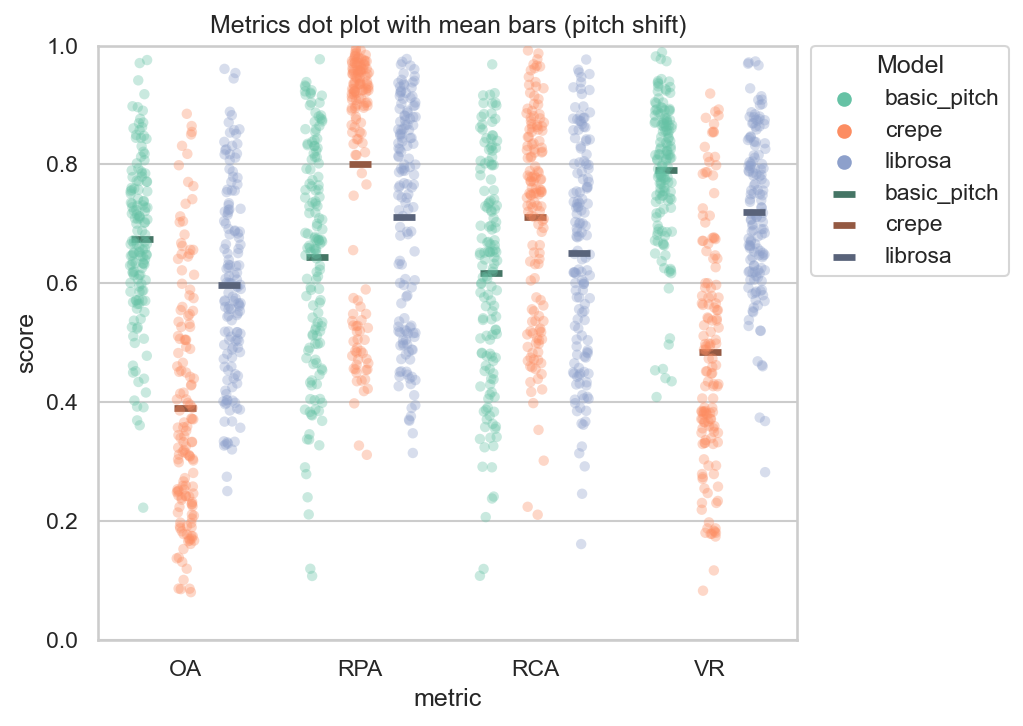

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

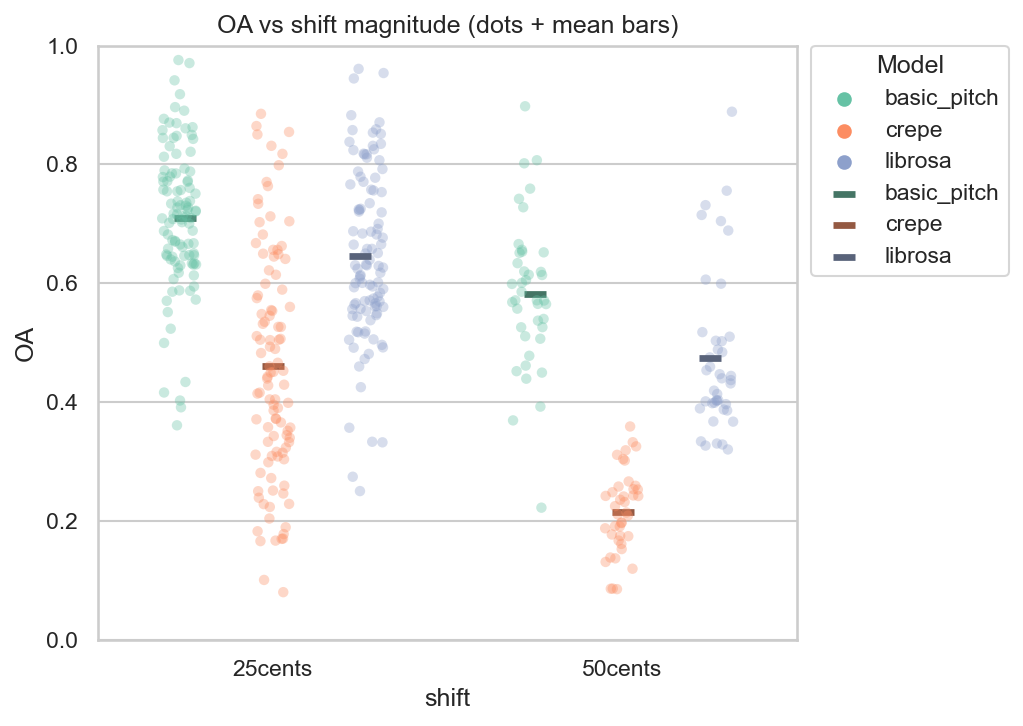

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.26966710777846514, 0.4568837962313781, 0.39739568702782224)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

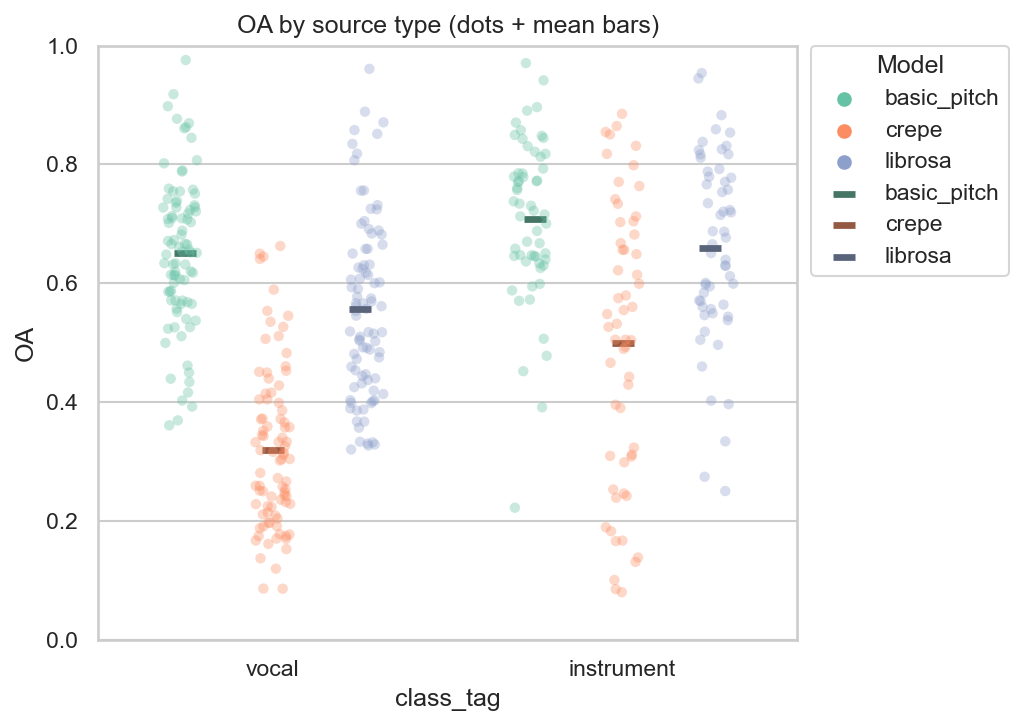

/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:1728: UserWarning: You passed a edgecolor/edgecolors ((0.5432199095466269, 0.11796843348973814, 0.12194923109679687)) for an unfilled marker ('_').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/Users/qiaoheqi/anaconda3/lib/python3.11/site-packages/seaborn/categorical.p

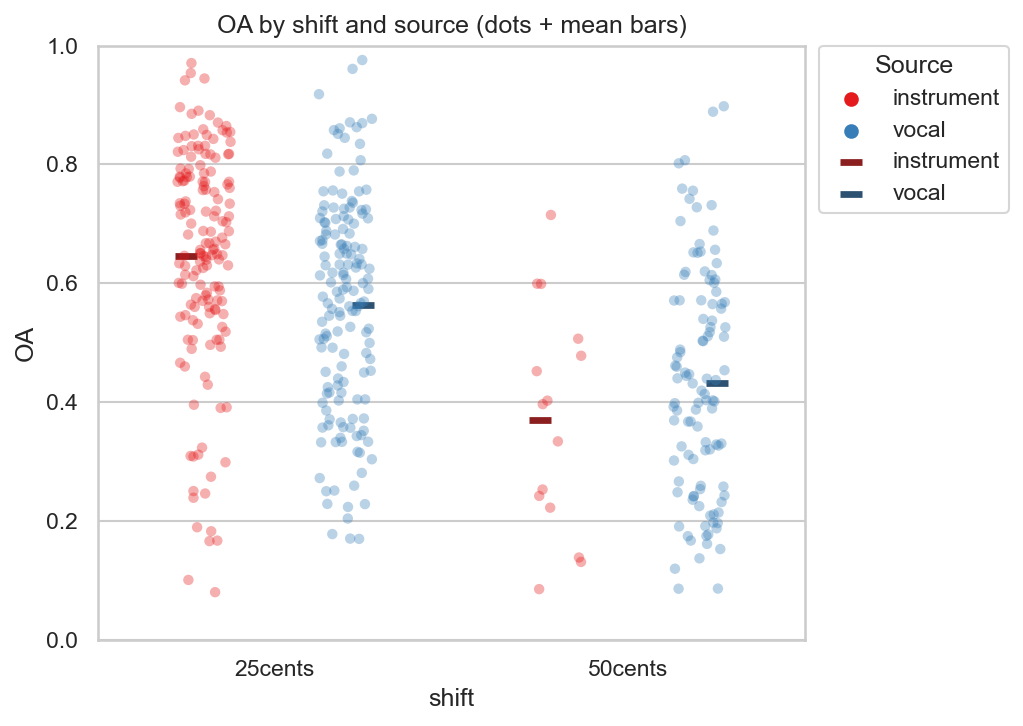

In [4]:
long_metrics = metrics.melt(
    id_vars=["filename", "model", "shift", "class_tag"],
    value_vars=["OA", "RPA", "RCA", "VR"],
    var_name="metric",
    value_name="score",
)

hue_order = sorted(metrics["model"].unique())
palette = sns.color_palette("Set2", n_colors=len(hue_order))
mean_palette = [sns.dark_palette(c, 3)[1] for c in palette]
color_map = dict(zip(hue_order, palette))
mean_map = dict(zip(hue_order, mean_palette))

class_order = sorted(metrics["class_tag"].unique())
class_palette = sns.color_palette("Set1", n_colors=len(class_order))
class_mean_palette = [sns.dark_palette(c, 3)[1] for c in class_palette]
class_mean_map = dict(zip(class_order, class_mean_palette))

# Plot 1: per-metric dots + mean bars
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=long_metrics,
    x="metric",
    y="score",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("Metrics dot plot with mean bars (pitch shift)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "metrics_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 2: OA vs shift magnitude
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="shift",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="shift",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA vs shift magnitude (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_shift_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 3: OA by source type
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=color_map,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="class_tag",
    y="OA",
    hue="model",
    hue_order=hue_order,
    palette=[mean_map[h] for h in hue_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by source type (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_source_dot_mean.png", bbox_inches="tight")
plt.show()

# Plot 4: OA by shift × source type
fig, ax = plt.subplots(figsize=(7, 5))

sns.stripplot(
    data=metrics,
    x="shift",
    y="OA",
    hue="class_tag",
    hue_order=class_order,
    palette=class_palette,
    dodge=True,
    alpha=0.35,
    jitter=0.15,
    ax=ax,
)
sns.pointplot(
    data=metrics,
    x="shift",
    y="OA",
    hue="class_tag",
    hue_order=class_order,
    palette=[class_mean_map[h] for h in class_order],
    dodge=0.5,
    join=False,
    markers="_",
    scale=1.6,
    linestyles="",
    errorbar=None,
    ax=ax,
)
ax.set_title("OA by shift and source (dots + mean bars)")
ax.set_ylim(0, 1)
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.savefig(out_dir / "oa_shift_source_dot_mean.png", bbox_inches="tight")
plt.show()
